# Regularizatie met SciKit-Learn

Voorheen hebben we een nieuwe polynomiale feature set gecreëerd en vervolgens onze standaard lineaire regressie daarop toegepast, maar we kunnen ook regularisatie gebruiken om ons model verder te verbeteren.

Regularisatie probeert de RSS (residual sum of squares) plus een penalty te minimaliseren. Deze penalty zal modellen bestraffen die te grote coëfficiënten hebben. Sommige regularisatiemethoden zullen er daadwerkelijk voor zorgen dat features ide geen meerwaarde hebben een coëfficiënt van nul hebben, in welk geval het model de feature niet in overweging neemt.

Laten we twee methoden van regularisatie verkennen: Ridge Regressie en Lasso. We zullen deze combineren met de polynomiale functieset (het zou niet zo effectief zijn om regularisatie van een model uit te voeren op zo'n kleine originele functieset van de oorspronkelijke X).

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data en Setup

In [2]:
df = pd.read_csv("data/Advertising.csv")
X = df.drop('sales',axis=1)
y = df['sales']

### Polynomial Conversion

In [3]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
polynomial_converter = PolynomialFeatures(degree=3, include_bias=False)
# adding features up to 3rd degree: original features plus TV**2, radio**2, TV*radio, etc.

In [5]:
poly_features = polynomial_converter.fit_transform(X)

### Train | Test Split

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
# 30% leave out for test

----
----

## Schalen van de data

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
# help(StandardScaler)

In [10]:
scaler = StandardScaler()

In [11]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [12]:
X_train = scaler.transform(X_train)

In [13]:
X_test = scaler.transform(X_test)

## Ridge Regression

In [14]:
from sklearn.linear_model import Ridge

In [15]:
# we starten met een initiële waarde alpha = 10
# Hier kunnen we maar één alpha meegeven!
ridge_model = Ridge(alpha=10)

In [16]:
# fit identiek aan voorheen!
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [17]:
test_predictions = ridge_model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

In [20]:
MAE

0.5774404204714166

In [21]:
RMSE # 0.9 for sales expressed in thousands dollars means 900 dollars naast de echte sales

np.float64(0.8946386461319648)

Hoe presteerde het op de trainingsset? (Dit zal later gebruikt worden ter vergelijking)

In [22]:
# Training Set Performance
train_predictions = ridge_model.predict(X_train)
MAE = mean_absolute_error(y_train, train_predictions)
MAE

0.5288348183025304

### Was deze alpha waarde goed? Bepalen van de alpha waarde door Cross-Validation

In [23]:
# Of alpha waarde van 10 goed is kunnen we niet weten zonder vergelijken
# CV wordt zo vaak gebruikt met Ridge Regression dat er een extra versie is!
# Bij CV wordt de gemiddelde fout berekend over de folds
from sklearn.linear_model import RidgeCV

In [24]:
from sklearn.metrics import get_scorer_names, make_scorer, mean_absolute_error

# List all available scorers
available_scorers = get_scorer_names()
print("Available Scorers:", available_scorers)

# Create a custom scorer for Mean Absolute Error
mae_scorer = make_scorer(mean_absolute_error) # standard is MAE negatief (met idee om die omhoog naar 0 te brengen)

# Now you can use mae_scorer in your model evaluation

Available Scorers: ['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 

In [25]:
# help(RidgeCV)

In [26]:
# Ridge moet weten op basis van welke parameter er moet worden geoptimaliseerd!
# alphas: welke is de best presterende sterkte voor de regularisatie parameter?
# scoring = None: 
# cv: int - hoeveel folds wil je doen in de cross validation? Als je dit weglaat: leave-one-out
# Herinner: negatieve RMSE omdat "Hoger is beter" geldt...
# Alle opties: sklearn.metrics.SCORERS.keys()
# scoring metric is optioneel!
ridge_cv_model = RidgeCV(alphas=(0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')
# waarom alpha tss 0 en 10: 0 is geen regularisatie, vanaf 10 is het niet veel meer zal veranderen.

# met aantal folds gedefinieerd:
# ridge_cv_model = RidgeCV(alphas=(0.1, 1.0, 10.0), cv=10, scoring='neg_mean_absolute_error')

In [27]:
# Hoe meer waarden voor alpha je doorgeeft, hoe langer dit zal duren...
# Onze dataset is klein dus dit is nog geen probleem!
# Hyperparameter tuning ENKEL op de train set!
ridge_cv_model.fit(X_train, y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.01, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",'neg_mean_absolute_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [28]:
# dus, wat was de beste alpha? maar enkel beste van wat we hebben meegegeven
ridge_cv_model.alpha_

0.03

In [29]:
# de test set is hier een soort hold out test set aangezien we er niet op hebben getuned!
test_predictions = ridge_cv_model.predict(X_test)

In [30]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

In [31]:
MAE

0.4096224723574553

In [32]:
RMSE # alpha 10 was te strenge regularisatie, 0.3 is beter (een beetje regularisatie)

np.float64(0.5901038129182627)

In [33]:
# Training Set Performance
# Training Set Performance
train_predictions = ridge_cv_model.predict(X_train)
MAE = mean_absolute_error(y_train,train_predictions)
MAE

0.29013123625137693

In [34]:
ridge_cv_model.coef_ # dit zijn theta's: gewichten bij de features

array([ 6.43507716,  0.52705718,  0.33934369, -8.61654588,  4.95591969,
       -1.53915625, -1.29091779,  0.70904477,  0.19458354,  3.96348164,
       -1.51058741,  1.26854012,  0.51645572, -0.30047744,  0.08424225,
        0.6531423 , -0.27979037, -0.16265522, -0.18484187])

* Meervoudige Lineair Regressie:
    * MAE: 1.213
    * RMSE: 1.516

* Polynomial 2-degree:
    * MAE: 0.4896
    * RMSE: 0.664
    
* Ridge 3-degree:
    * MAE: 0.29
    * RMSE: 0.59

In [35]:
# Map de coefs met hun respectievelijke feature names:
# RidgeCV is a linear regression model (with L2 regularization), not a classifier.
# Unlike LogisticRegression, it doesn’t track feature names internally, so model.coef_ is just a NumPy array.
# That means the order of coefficients exactly matches the order of columns in the input X you used to fit it.
features = polynomial_converter.get_feature_names_out(X.columns)
coef_features = pd.Series(ridge_cv_model.coef_, index=features)
coef_features

TV                    6.435077
radio                 0.527057
newspaper             0.339344
TV^2                 -8.616546
TV radio              4.955920
TV newspaper         -1.539156
radio^2              -1.290918
radio newspaper       0.709045
newspaper^2           0.194584
TV^3                  3.963482
TV^2 radio           -1.510587
TV^2 newspaper        1.268540
TV radio^2            0.516456
TV radio newspaper   -0.300477
TV newspaper^2        0.084242
radio^3               0.653142
radio^2 newspaper    -0.279790
radio newspaper^2    -0.162655
newspaper^3          -0.184842
dtype: float64


-----

## LASSO - least absolute shrinkage and selection operator

In [36]:
# je kan ook gewoon Lasso importeren, waarbij je dan zelf een alpha moet geven!
# je weet normaal de beste alpha waarde niet, dus voer je beter cross validation uit
from sklearn.linear_model import LassoCV

In [37]:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html
# eps: ratio tussen min en max alpha waarde
# n_alphas: aantal alphas die worden gecontroleerd
# cv: # folds in k-fold cross validation
lasso_cv_model = LassoCV(eps=0.001, alphas=100, cv=5)

In [38]:
lasso_cv_model.fit(X_train, y_train)

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.870e+00, tolerance: 3.684e-01
  model = cd_fast.enet_coordinate_descent(


,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [39]:
# deze warning zegt dat de zoektocht naar de beste waarde voor alpha niet succesvol was.  
# Je kan dit fixen door meer iteraties: max_iter=1000

In [40]:
lasso_cv_model = LassoCV(eps=0.001, alphas=100, cv=5, max_iter=1000000)

In [41]:
lasso_cv_model.fit(X_train, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [42]:
# een andere manier om dit te fixen: niet zo breed zoeken inzake de alphas.  Stel eps=0.1
lasso_cv_model = LassoCV(eps=0.1, alphas=100, cv=5, max_iter=1000)
lasso_cv_model.fit(X_train, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.1
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [43]:
# Wat was nu de beste alpha value?
lasso_cv_model.alpha_

np.float64(0.517843895166131)

In [44]:
# laat model voorspellen!
test_predictions = lasso_cv_model.predict(X_test)

In [45]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)
RMSE = np.sqrt(MSE)

In [46]:
MAE

0.6632006949946664

In [47]:
RMSE

np.float64(1.144793686013509)

In [48]:
# Training Set Performance
# Training Set Performance
train_predictions = lasso_cv_model.predict(X_train)
MAE = mean_absolute_error(y_train,train_predictions)
MAE

0.701426826363376

* Meervoudige Lineair Regressie:
    * MAE: 1.213
    * RMSE: 1.516

* Polynomial 2-degree:
    * MAE: 0.4896
    * RMSE: 0.664
    
* Ridge 3-degree:
    * MAE: 0.29
    * RMSE: 0.59
    
* Lasso 3-degree met de constraints die we gaven:
    * MAE: 0.65
    * RMSE: 1.13

In [49]:
# Gegeven de constraints aan het model presteert lasso niet zo goed als ridge. Wat is dan het voordeel van lasso?
# Bekijk even de coëfficiënten:

In [50]:
lasso_cv_model.coef_

array([0.98833797, 0.        , 0.        , 0.        , 3.78321358,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

## Elastic Net

Elastic Net combineert de penalties van ridge regression en lasso in een poging het beste van beide te krijgen.  

In [51]:
from sklearn.linear_model import ElasticNetCV

In [52]:
elastic_model = ElasticNetCV()

In [53]:
# l1_ratio: de ratio tussen L1 en L2 regularisatie. Geeft de "hoeveelheid lasso"
# dit komt overeen met de alpha van de formule
# Aangeraden wordt om dicht bij 1 te gaan voor deze parameter.
# eps en n_alphas: zie lasso
# de alphas in n_alphas is de lambda in de formule
# max_iter moeten we misschien ook aanpassen
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7,.9, .95, .99, 1], eps=0.001, alphas=100, max_iter=1000000)

In [54]:
elastic_model.fit(X_train, y_train)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.5, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [55]:
elastic_model.l1_ratio_

np.float64(1.0)

geen ridge, 100% lasso!

In [56]:
test_predictions = elastic_model.predict(X_test)

In [57]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [58]:
MAE

0.433503461859009

In [59]:
RMSE

np.float64(0.6063140748984053)

In [60]:
# Training Set Performance
# Training Set Performance
train_predictions = elastic_model.predict(X_train)
MAE = mean_absolute_error(y_train,train_predictions)
MAE

0.3307056225674514

In [61]:
elastic_model.coef_

array([ 4.86023329,  0.12544598,  0.20746872, -4.99250395,  4.38026519,
       -0.22977201, -0.        ,  0.07267717, -0.        ,  1.77780246,
       -0.69614918, -0.        ,  0.12044132, -0.        , -0.        ,
       -0.        ,  0.        ,  0.        , -0.        ])

Dit lasso model presteert beter dan het vorige, omdat de overige parameters het model toelieten om verder te zoeken...

-----
---

In [62]:
from sklearn.linear_model import Lasso

train_r2 = []
test_r2 = []
alphas = np.logspace(-4, 1, 10000)

for alpha in alphas:
    this_model = Lasso(alpha=alpha,tol=0.0001,fit_intercept=True, max_iter=1000000)
    this_model.fit(X_train,y_train)         
    test_r2.append(this_model.score(X_test,y_test))
    train_r2.append(this_model.score(X_train,y_train))

Text(0, 0.5, 'R² Performance')

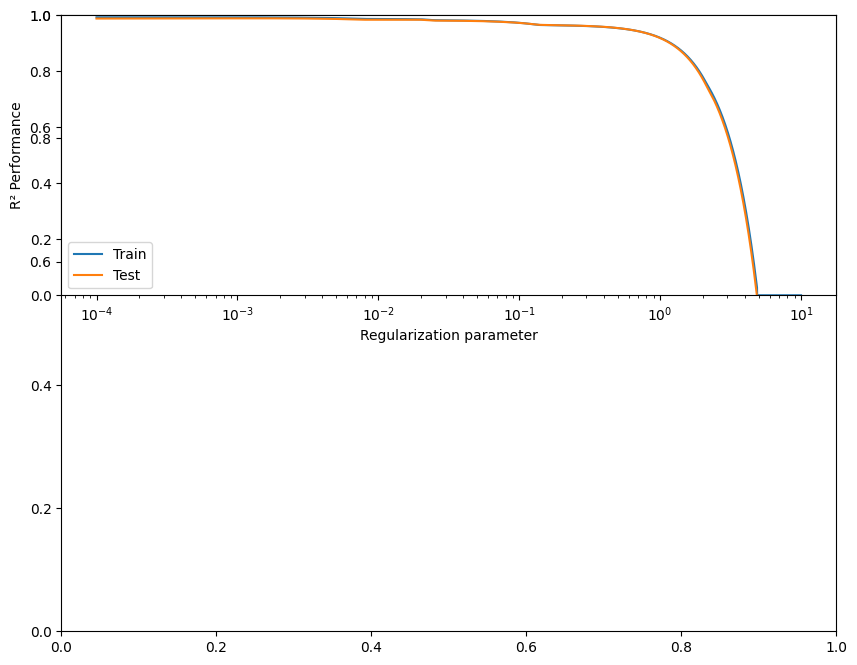

In [63]:
# Plot r2
f, ax = plt.subplots(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.semilogx(alphas, train_r2, label='Train')
plt.semilogx(alphas, test_r2, label='Test')
plt.legend(loc='lower left')
plt.ylim([0, 1])
plt.xlabel('Regularization parameter')
plt.ylabel('R² Performance')

## Subset selection

In [ ]:
## Subset selection met cross validation - meest voorkomend in het praktijk
import itertools
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def best_subset_selection(X, y, k_fold=5):
    # Predictors
    n_predictors = X.shape[1]
    predictors = X.columns
    # Initialiseer de beste score als - oneindig
    best_score = float('-inf')
    best_subset = []

    # Loop door elk mogelijk aantal predictors
    for k in range(1, n_predictors + 1):
        # Maak alle subsets die mogelijk zijn door 'k' elementen uit de set predictors te kiezen (binomiaalcoëfficiënt)
        subsets = itertools.combinations(predictors, k)
        # ga nu door elk van deze subsets met k elementen heen, en bewaar de beste subset
        for subset in subsets:
            # Fit model en cross-validate
            model = LinearRegression()
            subset = list(subset) 
            scores = cross_val_score(model, X[subset], y, cv=k_fold, scoring='neg_mean_squared_error') # train het model met de subset en return score per fold
            score = scores.mean()

            # Update best score and best subset
            if score > best_score:
                print(f"New best subset: {subset} with score {score}")
                best_score = score
                best_subset = subset

    return best_subset, best_score

In [66]:
# opnieuw naar 9 features (geen regularisatie)
df = pd.read_csv("data/Advertising.csv")
X = df.drop('sales',axis=1)
y = df['sales']

In [67]:
polynomial_converter = PolynomialFeatures(degree=2,include_bias=False)

In [68]:
poly_features = polynomial_converter.fit_transform(X)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [70]:
scaler = StandardScaler()
scaler.fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)

array([[-9.13394717e-01,  1.76259419e+00,  6.81685579e-01,
        -9.63975055e-01,  1.52122095e-02, -2.93048209e-01,
         2.31532893e+00,  1.56001049e+00,  3.69910106e-01],
       [ 1.23121149e+00,  2.36559587e-01, -1.19601922e+00,
         1.38103193e+00,  9.76521639e-01, -6.80562258e-01,
        -5.79325829e-02, -7.40162021e-01, -7.79189389e-01],
       [-4.60024728e-01, -4.07766136e-01,  3.50051150e-01,
        -6.82242743e-01, -5.06457342e-01, -1.10940195e-01,
        -6.39722074e-01, -1.69172158e-01,  3.57554301e-02],
       [-4.96816533e-01,  1.65407618e+00,  9.47927303e-01,
        -7.09383526e-01,  4.86260118e-01,  1.37061544e-01,
         2.10033570e+00,  1.77735495e+00,  6.78908133e-01],
       [-1.42610633e+00,  8.05649381e-02, -1.35015916e+00,
        -1.14433859e+00, -8.66050574e-01, -9.38134722e-01,
        -2.21679679e-01, -8.42466779e-01, -7.93375596e-01],
       [-1.56971305e+00, -5.02719400e-01, -4.11306765e-01,
        -1.16855131e+00, -1.00646472e+00, -8.680574

In [72]:
# maak een pandas dataframe van de numpy ndarray
columns = ['TV', 'radio', 'newspaper', 'TV*TV', 'TV*radio', 'TV*newspaper', 'radio*radio', 'radio*newspaper', 'newspaper*newspaper']
X_df = pd.DataFrame(X_train, columns=columns)

# call de functie
best_subset, best_score = best_subset_selection(X_df, y_train)
print(f"Best subset: {best_subset}")
print(f"Best cross-validated MSE: {best_score}")

New best subset: ['TV'] with score -10.695488978724429
New best subset: ['TV*radio'] with score -1.9245457480238422
New best subset: ['TV', 'TV*radio'] with score -0.9440578474342376
New best subset: ['TV', 'TV*TV', 'TV*radio'] with score -0.4601904214974703
New best subset: ['TV', 'radio', 'TV*TV', 'TV*radio'] with score -0.4316518619385836
New best subset: ['TV', 'TV*TV', 'TV*radio', 'radio*radio'] with score -0.4273868235543644
New best subset: ['TV', 'TV*TV', 'TV*radio', 'radio*newspaper'] with score -0.4130330902713496
New best subset: ['TV', 'newspaper', 'TV*TV', 'TV*radio', 'radio*newspaper'] with score -0.40941645478813626
New best subset: ['TV', 'TV*TV', 'TV*radio', 'TV*newspaper', 'radio*newspaper'] with score -0.3971551595190898
Best subset: ['TV', 'TV*TV', 'TV*radio', 'TV*newspaper', 'radio*newspaper']
Best cross-validated MSE: -0.3971551595190898


In [ ]:
# Train het model opnieuw op X_train data met de beste subset

In [73]:
X_df.head()

,TV,radio,newspaper,TV*TV,TV*radio,TV*newspaper,radio*radio,radio*newspaper,newspaper*newspaper
0,193.2,18.4,65.7,37326.24,3554.88,12693.24,338.56,1208.88,4316.49
1,287.6,43.0,71.8,82713.76,12366.80,20649.68,1849.00,3087.40,5155.24
2,80.2,0.0,9.2,6432.04,0.00,737.84,0.00,0.00,84.64
3,182.6,46.2,58.7,33342.76,8436.12,10718.62,2134.44,2711.94,3445.69
4,222.4,4.3,49.8,49461.76,956.32,11075.52,18.49,214.14,2480.04


In [75]:
X_df[best_subset].head()

,TV,TV*TV,TV*radio,TV*newspaper,radio*newspaper
0,193.2,37326.24,3554.88,12693.24,1208.88
1,287.6,82713.76,12366.80,20649.68,3087.40
2,80.2,6432.04,0.00,737.84,0.00
3,182.6,33342.76,8436.12,10718.62,2711.94
4,222.4,49461.76,956.32,11075.52,214.14


In [76]:
model = LinearRegression()

In [77]:
model.fit(X_df[best_subset], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
# convert X_test to dataframe

X_test_df = pd.DataFrame(X_test, columns=columns)
y_pred = model.predict(X_test_df[best_subset])

In [79]:
MAE = mean_absolute_error(y_test, y_pred)
MAE

0.5060704629021661

In [80]:
MSE = mean_squared_error(y_test, y_pred)
MSE

0.4780722262304145

In [81]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.6914276724505714)

* Meervoudige Lineair Regressie:
    * MAE: 1.213
    * RMSE: 1.516

* Polynomial 2-degree:
    * MAE: 0.4896
    * RMSE: 0.664
    
* Ridge 3-degree:
    * MAE: 0.29
    * RMSE: 0.59
    
* Lasso 3-degree met de constraints die we gaven (2 features):
    * MAE: 0.65
    * RMSE: 1.13

* Subset Selection (5 features):
    * MAE: 0.5
    * RMSE: 0.69

## Stepwise selection - forward selection

In [ ]:
def forward_selection(X, y, k_fold): # nog een manier om tot een selectie te komen
    remaining_features = list(X.columns)
    best_subset = []
    best_score = float('inf')  # initialiseer met positief oneindig
    
    while remaining_features:
        scores_with_candidates = []

        for candidate in remaining_features:
            model = LinearRegression()
            scores = cross_val_score(model, X[best_subset + [candidate]], y, cv=k_fold, scoring='neg_mean_squared_error')
            score = -scores.mean()  # Negatief omdat de score die cross_val_score returns negatief is
            scores_with_candidates.append((score, candidate))

        # Sorteer oplopend omdat een lagere MSE beter is
        scores_with_candidates.sort()
        
        # Check of we een nieuwe beste subset hebben gevonden
        if scores_with_candidates[0][0] < best_score:
            best_score = scores_with_candidates[0][0]
            best_subset.append(scores_with_candidates[0][1])
            remaining_features.remove(scores_with_candidates[0][1])
            print(f"New best subset: {best_subset} with MSE {best_score}")
        else:
            # Break indien geen verbetering ("early stopping")
            break

    return best_score, best_subset

In [83]:
best_score, best_subset = forward_selection(X_df, y_train, 5)

New best subset: ['TV*radio'] with MSE 1.9245457480238422
New best subset: ['TV*radio', 'TV'] with MSE 0.944057847434237
New best subset: ['TV*radio', 'TV', 'TV*TV'] with MSE 0.4601904214975125
New best subset: ['TV*radio', 'TV', 'TV*TV', 'radio*newspaper'] with MSE 0.4130330902714131
New best subset: ['TV*radio', 'TV', 'TV*TV', 'radio*newspaper', 'TV*newspaper'] with MSE 0.3971551595190916


Gevonden door Subset Selection: `['TV', 'TV*TV', 'TV*radio', 'TV*newspaper', 'radio*newspaper']` - identiek!

* Meervoudige Lineair Regressie:
    * MAE: 1.213
    * RMSE: 1.516

* Polynomial 2-degree:
    * MAE: 0.4896
    * RMSE: 0.664
    
* Ridge 3-degree:
    * MAE: 0.29
    * RMSE: 0.59
    
* Lasso 3-degree met de constraints die we gaven (2 features):
    * MAE: 0.65
    * RMSE: 1.13

* Subset Selection (5 features):
    * MAE: 0.5
    * RMSE: 0.69

* Stepwise selection - forward (5 features):
    * Identiek als subset selection